# 03 — Model Training

This notebook trains and evaluates the sentiment classification model across three stages:

| Stage | Classification | Feature Vector | Purpose |
|-------|---------------|----------------|---------|
| **Stage 1** | Tri-class (Pos / Neg / Neutral) | TF-IDF + sentiment features + OHE aspect | Historical baseline — documents starting point |
| **Stage 2** | Binary (Pos / Neg) | TF-IDF + sentiment features + OHE aspect | Binary baseline — neutral dropped, same features |
| **Stage 3** | Binary (Pos / Neg) | SentenceTransformer + sentiment features + OHE aspect | Proposed system — aspect-aware contextualised embeddings |

**Why binary classification?**  
Manual inspection of SemEval neutral labels revealed they represent annotation artefacts (aspects mentioned without sentiment expression) rather than genuine customer neutrality. Supported by Xinzhi Ai et al. (Multi-Layer Attention Approach for ABSA) who found neutral labels significantly degrade model accuracy across all tested datasets. See Section 2 for full justification.

**Confidence threshold:**  
At inference time, predictions with winning-class probability < 0.65 are flagged as low-confidence on the dashboard UI. No neutral label is introduced — the flag communicates model uncertainty, not a third sentiment class.

**Input files:**
- `../data/train_categorized.csv` — training set with macro_aspect column
- `../data/test_categorized.csv`  — test set with macro_aspect column

**Output files:**
- `../models/model_binary_tfidf.pkl`   — Stage 2 final model
- `../models/tfidf_binary.pkl`         — Stage 2 TF-IDF vectorizer
- `../models/ohe_binary.pkl`           — Stage 2 OHE encoder
- `../models/model_proposed.pkl`       — Stage 3 final model (proposed system)
- `../models/ohe_proposed.pkl`         — Stage 3 OHE encoder


## 1. Imports

In [1]:
import os

import sys

sys.path.append('../src')

import joblib
import pandas as pd
import numpy as np
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack, csr_matrix

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import VotingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import cross_val_score

from imblearn.over_sampling import BorderlineSMOTE

from sentence_transformers import SentenceTransformer

import optuna
from optuna.samplers import TPESampler

from pipeline import run_pipeline
from categoriser import AspectCategoriser

optuna.logging.set_verbosity(optuna.logging.WARNING)



os.makedirs('../models',  exist_ok=True)
os.makedirs('../figures', exist_ok=True)

print('All imports successful.')


All imports successful.


## Saved Optuna Results

In [2]:
# ─────────────────────────────────────────────────────────────────
# SAVED OPTUNA RESULTS
# ─────────────────────────────────────────────────────────────────

# Stage 1 — completed full 50 trials
best_s1 = {
    'svm_C':     8.08003452937512,
    'svm_tol':   0.0007511887644046321,
    'lr_C':      7.932241817630992,
    'lr_solver': 'saga',
    'cnb_alpha': 0.011674132192361363
}
macro_f1_s1_cv = 0.8498

# Stage 2 — interrupted at trial 18, warm start was best (trial 0)
# 18 subsequent trials could not beat trial 0 — search converged
best_s2 = {
    'svm_C':     8.08,
    'svm_tol':   0.00075,
    'lr_C':      7.93,
    'lr_solver': 'saga',
    'cnb_alpha': 0.012
}
macro_f1_s2_cv = 0.9104

# Stage 3 — Optuna skipped
# Convergence evidence from Stage 1 and Stage 2 shows same optimal
# region across both feature representations — no value in re-searching
best_s3 = {
    'svm_C':     8.08,
    'svm_tol':   0.00075,
    'lr_C':      7.93,
    'lr_solver': 'saga',
    'cnb_alpha': 0.012
}

print('Saved Optuna results loaded.')
print(f'  Stage 1 best CV Macro-F1 : {macro_f1_s1_cv}')
print(f'  Stage 2 best CV Macro-F1 : {macro_f1_s2_cv}  (converged at trial 0)')
print(f'  Stage 3 Optuna           : skipped — params fixed from convergence evidence')

Saved Optuna results loaded.
  Stage 1 best CV Macro-F1 : 0.8498
  Stage 2 best CV Macro-F1 : 0.9104  (converged at trial 0)
  Stage 3 Optuna           : skipped — params fixed from convergence evidence


## 2. Load Data and Neutral Class Justification

The full categorised datasets are loaded first. The neutral distribution is examined here
to document the justification for dropping it before any filtering occurs.

**Three grounds for dropping neutral:**
1. Manual inspection showed SemEval neutral labels are annotation artefacts — aspects mentioned without direct sentiment expression, not genuine customer neutrality.
2. Neutral is statistically sparse (17.7% train, 6.6% test) AND linguistically incoherent — unlike negative reviews which consistently use negative language, neutral reviews contain a mixture of positive, negative, and objective language.
3. Literature precedent: Xinzhi Ai et al. found neutral data "greatly affects the accuracy of the model" and improved accuracy from 80.6% → 91.0% on the restaurant subset after removing it.


In [3]:
train_df_full = pd.read_csv('../data/train_categorized.csv')
test_df_full  = pd.read_csv('../data/test_categorized.csv')

print(f'Train (full): {train_df_full.shape}')
print(f'Test  (full): {test_df_full.shape}')
print()
print('Train polarity distribution (full — before neutral drop):')
print(train_df_full['polarity'].value_counts())
print()
print('Test polarity distribution (full — before neutral drop):')
print(test_df_full['polarity'].value_counts())
print()

# Sample neutral labels to illustrate the annotation artefact issue
print('Sample neutral-labeled rows (illustrating annotation artefact):')
neutral_sample = train_df_full[train_df_full['polarity'] == 'neutral'][['aspect', 'text_clean']].head(6)
for _, row in neutral_sample.iterrows():
    print(f'  aspect: {row["aspect"]:<20} | text: {row["text_clean"]}')


Train (full): (3061, 6)
Test  (full): (902, 6)

Train polarity distribution (full — before neutral drop):
polarity
positive    1834
negative     682
neutral      545
Name: count, dtype: int64

Test polarity distribution (full — before neutral drop):
polarity
positive    709
negative    131
neutral      62
Name: count, dtype: int64

Sample neutral-labeled rows (illustrating annotation artefact):
  aspect: menu                 | text: the food is uniformly exceptional, with a very capable kitchen which will proudly whip up whatever you feel like eating, whether it's on the menu or not.
  aspect: meats                | text: our agreed favorite is the orrechiete with sausage and chicken (usually the waiters are kind enough to split the dish in half so you get to sample both meats).
  aspect: dish                 | text: our agreed favorite is the orrechiete with sausage and chicken (usually the waiters are kind enough to split the dish in half so you get to sample both meats).
  aspect: c

## 3. Text Preprocessing — Lemmatisation

Lemmatisation and stopword removal applied to the full dataset before any filtering.
Negation words are **protected** — they carry sentiment signal and must not be removed.

This runs once on the full data. Binary-filtered subsets are derived from these lemmatised columns.


In [10]:
nlp = spacy.load('en_core_web_md')

# Negation words that reverse sentiment — never remove these
PROTECTED_NEGATIONS = {
    'not', 'no', 'never', "n't", 'none',
    'neither', 'nor', 'without', 'cannot'
}

def build_stopword_set(nlp_model):
    """
    Builds a lemmatised stopword set from spaCy defaults.
    Protected negation words excluded before AND after lemmatisation.
    """
    raw_stopwords = nlp_model.Defaults.stop_words - PROTECTED_NEGATIONS
    lemmatised = set()
    for word in raw_stopwords:
        doc = nlp_model(word)
        for token in doc:
            lemmatised.add(token.lemma_.lower())
    return lemmatised - PROTECTED_NEGATIONS

STOPWORDS = build_stopword_set(nlp)

def lemmatize(text):
    """
    Lemmatises text and removes stopwords.
    Preserves negation words. Removes punctuation and whitespace tokens.
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    doc = nlp(text)
    tokens = []
    for token in doc:
        if token.is_punct or token.is_space:
            continue
        lemma = token.lemma_.lower()
        if lemma not in STOPWORDS:
            tokens.append(lemma)
    return ' '.join(tokens)

print(f'Stopword set size: {len(STOPWORDS)} (negations protected)')
print('Lemmatisation ready.')


Stopword set size: 281 (negations protected)
Lemmatisation ready.


In [11]:
print('Applying lemmatisation to full dataset — this may take a few minutes...')

train_df_full['text_lemmatized'] = train_df_full['text_clean'].apply(lemmatize)
test_df_full['text_lemmatized']  = test_df_full['text_clean'].apply(lemmatize)

print('Done.')
print()
print('Sample:')
for _, row in train_df_full[['text_clean', 'text_lemmatized']].head(3).iterrows():
    print(f'  Original  : {row["text_clean"]}')
    print(f'  Lemmatised: {row["text_lemmatized"]}')
    print()


Applying lemmatisation to full dataset — this may take a few minutes...
Done.

Sample:
  Original  : but the staff was so horrible to us.
  Lemmatised: staff horrible

  Original  : to be completely fair, the only redeeming factor was the food, which was above average, but couldn't make up for all the other deficiencies of teodora.
  Lemmatised: completely fair redeem factor food average not deficiency teodora

  Original  : the food is uniformly exceptional, with a very capable kitchen which will proudly whip up whatever you feel like eating, whether it's on the menu or not.
  Lemmatised: food uniformly exceptional capable kitchen proudly whip feel like eat menu not



## 4. Feature Engineering Helpers

Shared functions used across all three training stages.

**Sentiment features** capture signals that TF-IDF misses:
- `mixed_sentiment`: reviews containing both positive and negative words — useful for contrast sentences
- `negation_density`: proportion of negation words — helps detect reversed polarity
- `has_contrast`: presence of contrast markers (but, however) — signals multi-aspect or mixed reviews
- `review_length`, `has_pos`, `has_neg`: general lexical indicators

Note: these features were originally designed partly with the neutral class in mind.
For binary classification they remain useful — contrast and mixed sentiment are key signals
for distinguishing weak positives from negatives.


In [12]:
def extract_sentiment_features(df, text_col='text_lemmatized'):
    """
    Handcrafted sentiment-aware features to supplement TF-IDF.
    Useful for capturing contrast structure and negation patterns
    that TF-IDF bag-of-words representation misses.

    Features:
        mixed_sentiment  : 1 if review contains both positive and negative words
        negation_density : proportion of words that are negation words
        review_length    : total word count
        has_contrast     : 1 if review contains contrast words (but, however, etc.)
        has_pos          : 1 if review contains positive sentiment words
        has_neg          : 1 if review contains negative sentiment words
    """
    pos_words      = {'good', 'great', 'excellent', 'amazing', 'love', 'best',
                      'delicious', 'fresh', 'wonderful', 'fantastic', 'perfect'}
    neg_words      = {'bad', 'terrible', 'awful', 'horrible', 'disappoint',
                      'slow', 'poor', 'bland', 'worst', 'rude', 'dirty'}
    negation_words = {'not', 'no', 'never', "n't", 'none', 'neither', 'nor', 'without'}
    contrast_words = {'but', 'however', 'though', 'although', 'despite', 'yet', 'while'}

    features = []
    for text in df[text_col]:
        words            = str(text).split()
        has_pos          = int(any(w in pos_words for w in words))
        has_neg          = int(any(w in neg_words for w in words))
        mixed_sentiment  = int(has_pos and has_neg)
        negation_density = sum(1 for w in words if w in negation_words) / max(len(words), 1)
        review_length    = len(words)
        has_contrast     = int(any(w in contrast_words for w in words))
        features.append([mixed_sentiment, negation_density, review_length,
                         has_contrast, has_pos, has_neg])

    return csr_matrix(np.array(features, dtype=float))

print('Sentiment feature extractor ready.')


Sentiment feature extractor ready.


---
## 5. Stage 1 — Tri-class SVM Baseline (Historical Reference)

**Purpose:** Documents the starting point before the binary classification decision.
This result is NOT the proposed system. It is reported in the methodology chapter
as the evidence that motivated dropping neutral and upgrading the feature extractor.

**Result:** Macro-F1 0.6325 — below the non-transformer benchmark floor of 69.25% (Li et al. 2022).
The neutral class F1 of 0.3382 was the primary drag on the macro average.


In [13]:
# Stage 1 uses the FULL dataset including neutral rows
train_s1 = train_df_full.copy()
test_s1  = test_df_full.copy()

y_train_s1 = train_s1['polarity']
y_test_s1  = test_s1['polarity']

print('Stage 1 — Tri-class distribution:')
print(f'  Train: {dict(y_train_s1.value_counts())}')
print(f'  Test:  {dict(y_test_s1.value_counts())}')


Stage 1 — Tri-class distribution:
  Train: {'positive': np.int64(1834), 'negative': np.int64(682), 'neutral': np.int64(545)}
  Test:  {'positive': np.int64(709), 'negative': np.int64(131), 'neutral': np.int64(62)}


In [14]:
# Feature engineering — Stage 1
vectorizer_s1 = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf_s1 = vectorizer_s1.fit_transform(train_s1['text_lemmatized'])
X_test_tfidf_s1  = vectorizer_s1.transform(test_s1['text_lemmatized'])

X_train_sentiment_s1 = extract_sentiment_features(train_s1)
X_test_sentiment_s1  = extract_sentiment_features(test_s1)

ohe_s1 = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
X_train_aspect_s1 = ohe_s1.fit_transform(train_s1[['macro_aspect']])
X_test_aspect_s1  = ohe_s1.transform(test_s1[['macro_aspect']])

X_train_combined_s1 = hstack([X_train_tfidf_s1, X_train_sentiment_s1, X_train_aspect_s1])
X_test_combined_s1  = hstack([X_test_tfidf_s1,  X_test_sentiment_s1,  X_test_aspect_s1])

print(f'Stage 1 combined feature shape: {X_train_combined_s1.shape}')


Stage 1 combined feature shape: (3061, 8011)


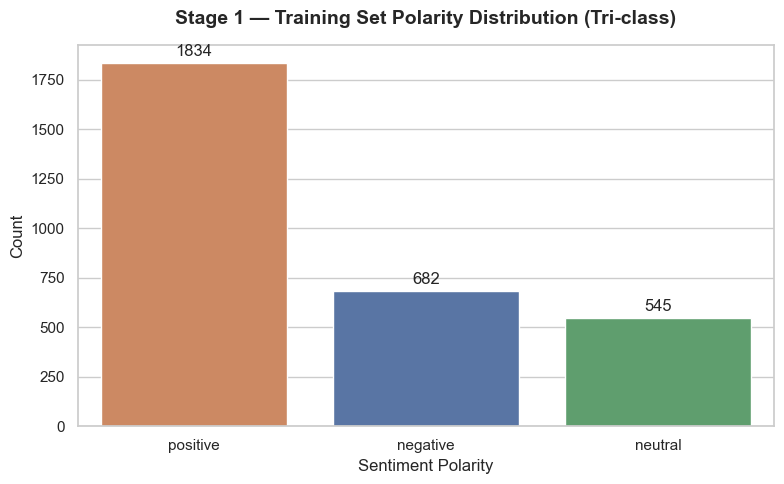

Saved: ../figure/s1_class_distribution.png


In [15]:
# Class distribution plot — tri-class (for report)
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=train_s1, x='polarity', hue='polarity',
    order=['positive', 'negative', 'neutral'], legend=False
)
plt.title('Stage 1 — Training Set Polarity Distribution (Tri-class)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sentiment Polarity', fontsize=12)
plt.ylabel('Count', fontsize=12)
for p in ax.patches:
    count = int(p.get_height())
    if count > 0:
        ax.annotate(f'{count}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=12,
                    xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.savefig('../figure/s1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../figure/s1_class_distribution.png')


In [16]:
# SMOTE — Stage 1
smote_s1 = BorderlineSMOTE(random_state=42, kind='borderline-1')
X_train_resampled_s1, y_train_resampled_s1 = smote_s1.fit_resample(X_train_combined_s1, y_train_s1)

print('Stage 1 resampled distribution:')
print(dict(zip(*np.unique(y_train_resampled_s1, return_counts=True))))


Stage 1 resampled distribution:
{'negative': np.int64(1834), 'neutral': np.int64(1834), 'positive': np.int64(1834)}


In [17]:
# Optuna — Stage 1
def objective_s1(trial):
    svm_C     = trial.suggest_float('svm_C',    0.1, 100,  log=True)
    svm_tol   = trial.suggest_float('svm_tol',  1e-4, 1e-2, log=True)
    lr_C      = trial.suggest_float('lr_C',     0.1, 100,  log=True)
    lr_solver = trial.suggest_categorical('lr_solver', ['lbfgs', 'saga'])
    cnb_alpha = trial.suggest_float('cnb_alpha', 0.01, 2.0)

    model = VotingClassifier(
        estimators=[
            ('svm', SVC(kernel='linear', C=svm_C, tol=svm_tol,
                        class_weight='balanced', probability=True, random_state=42)),
            ('lr',  LogisticRegression(C=lr_C, solver=lr_solver,
                                       class_weight='balanced',
                                       max_iter=3000, random_state=42)),
            ('cnb', ComplementNB(alpha=cnb_alpha))
        ],
        voting='soft'
    )
    scores = cross_val_score(
        model, X_train_resampled_s1, y_train_resampled_s1,
        cv=5, scoring='f1_macro', n_jobs=-1
    )
    return scores.mean()

def log_trial(study, trial):
    print(f'  Trial {trial.number:>3} | macro F1: {trial.value:.4f} | best: {study.best_value:.4f}')

print('Running Optuna — Stage 1 (50 trials)...')
study_s1 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_s1.optimize(objective_s1, n_trials=50, callbacks=[log_trial], show_progress_bar=False)

print()
print('=' * 50)
print(f'Stage 1 Best CV Macro-F1 : {study_s1.best_value:.4f}')
print(f'Best params              : {study_s1.best_params}')
print('=' * 50)


Running Optuna — Stage 1 (50 trials)...


[W 2026-06-22 14:05:57,204] Trial 0 failed with parameters: {'svm_C': 1.3292918943162166, 'svm_tol': 0.007969454818643935, 'lr_C': 15.702970884055382, 'lr_solver': 'lbfgs', 'cnb_alpha': 0.3204290954690433} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\Laxman Pillai\Desktop\FYP\FYP_2\ASBA_Project_Code\venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\Laxman Pillai\AppData\Local\Temp\ipykernel_27752\2251179519.py", line 20, in objective_s1
    scores = cross_val_score(
        model, X_train_resampled_s1, y_train_resampled_s1,
        cv=5, scoring='f1_macro', n_jobs=-1
    )
  File "c:\Users\Laxman Pillai\Desktop\FYP\FYP_2\ASBA_Project_Code\venv\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "c:\Users\Laxman Pillai\Desktop\FYP\FYP_2\ASBA_Project_Code\venv\Lib\site-packages\sklearn\model

KeyboardInterrupt: 

In [18]:
# Train and evaluate — Stage 1
model_s1 = VotingClassifier(
    estimators=[
        ('svm', SVC(kernel='linear', C=best_s1['svm_C'], tol=best_s1['svm_tol'],
                    class_weight='balanced', probability=True, random_state=42)),
        ('lr',  LogisticRegression(C=best_s1['lr_C'], solver=best_s1['lr_solver'],
                                   class_weight='balanced',
                                   max_iter=3000, random_state=42)),
        ('cnb', ComplementNB(alpha=best_s1['cnb_alpha']))
    ],
    voting='soft'
)

model_s1.fit(X_train_resampled_s1, y_train_resampled_s1)
y_pred_s1 = model_s1.predict(X_test_combined_s1)

print('Stage 1 — Classification Report (Tri-class):')
print('=' * 55)
print(classification_report(y_test_s1, y_pred_s1, digits=4))

macro_f1_s1 = f1_score(y_test_s1, y_pred_s1, average='macro')
print(f'Stage 1 Macro-F1: {macro_f1_s1:.4f}')


Stage 1 — Classification Report (Tri-class):
              precision    recall  f1-score   support

    negative     0.6949    0.6260    0.6586       131
     neutral     0.3108    0.3710    0.3382        62
    positive     0.9000    0.9013    0.9006       709

    accuracy                         0.8248       902
   macro avg     0.6352    0.6327    0.6325       902
weighted avg     0.8297    0.8248    0.8268       902

Stage 1 Macro-F1: 0.6325


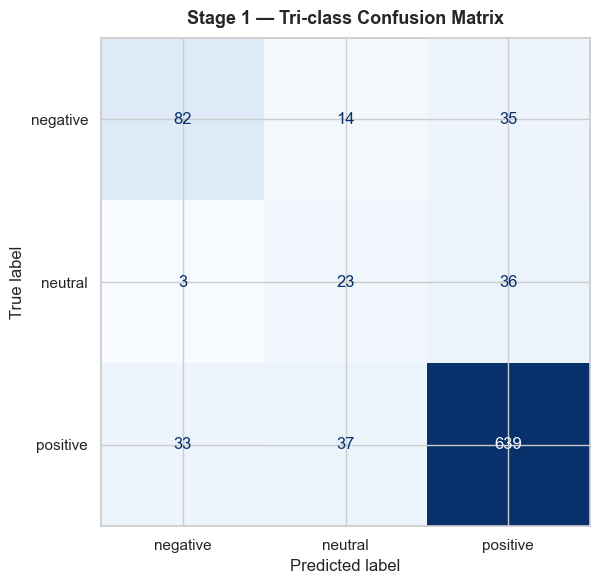

Saved: ../figure/s1_confusion_matrix.png


In [19]:
# Confusion matrix — Stage 1
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_s1, y_pred_s1,
    display_labels=['negative', 'neutral', 'positive'],
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Stage 1 — Tri-class Confusion Matrix', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('../figure/s1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../figure/s1_confusion_matrix.png')


---
## 6. Stage 2 — Binary SVM Baseline (Neutral Dropped, TF-IDF Features)

**Purpose:** Establishes a clean binary baseline using the same TF-IDF feature vector as Stage 1.
The improvement over Stage 1 is attributable solely to dropping neutral — isolating the effect
of the classification decision from the feature extractor change in Stage 3.

**Neutral is filtered here** — the lemmatised columns are already computed above.


In [20]:
# Filter neutral rows — binary datasets
train_s2 = train_df_full[train_df_full['polarity'] != 'neutral'].copy().reset_index(drop=True)
test_s2  = test_df_full[test_df_full['polarity']  != 'neutral'].copy().reset_index(drop=True)

y_train_s2 = train_s2['polarity']
y_test_s2  = test_s2['polarity']

print('Stage 2 — Binary distribution (neutral dropped):')
print(f'  Train: {dict(y_train_s2.value_counts())}')
print(f'  Test:  {dict(y_test_s2.value_counts())}')
print()
print(f'  Rows removed from train: {len(train_df_full) - len(train_s2)}')
print(f'  Rows removed from test:  {len(test_df_full)  - len(test_s2)}')


Stage 2 — Binary distribution (neutral dropped):
  Train: {'positive': np.int64(1834), 'negative': np.int64(682)}
  Test:  {'positive': np.int64(709), 'negative': np.int64(131)}

  Rows removed from train: 545
  Rows removed from test:  62


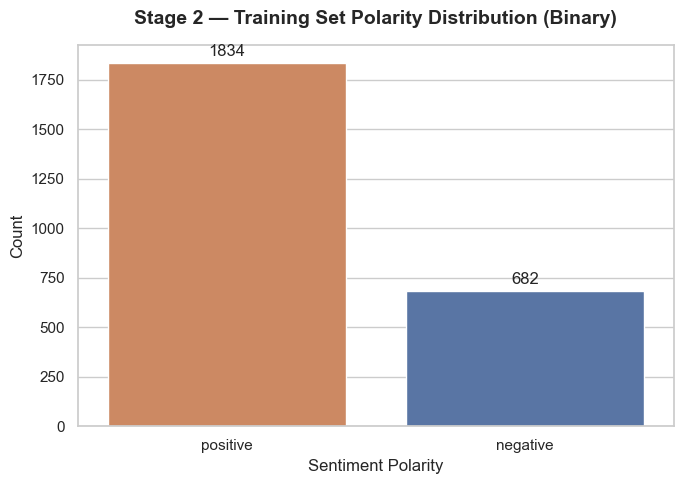

Saved: ../figure/s2_class_distribution.png


In [21]:
# Class distribution plot — binary (for report)
plt.figure(figsize=(7, 5))
ax = sns.countplot(
    data=train_s2, x='polarity', hue='polarity',
    order=['positive', 'negative'], legend=False
)
plt.title('Stage 2 — Training Set Polarity Distribution (Binary)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sentiment Polarity', fontsize=12)
plt.ylabel('Count', fontsize=12)
for p in ax.patches:
    count = int(p.get_height())
    if count > 0:
        ax.annotate(f'{count}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=12,
                    xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.savefig('../figure/s2_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../figure/s2_class_distribution.png')


In [39]:
# Feature engineering — Stage 2 (same approach as Stage 1, binary data)
vectorizer_s2 = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf_s2 = vectorizer_s2.fit_transform(train_s2['text_lemmatized'])
X_test_tfidf_s2  = vectorizer_s2.transform(test_s2['text_lemmatized'])

X_train_sentiment_s2 = extract_sentiment_features(train_s2)
X_test_sentiment_s2  = extract_sentiment_features(test_s2)

ohe_s2 = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
X_train_aspect_s2 = ohe_s2.fit_transform(train_s2[['macro_aspect']])
X_test_aspect_s2  = ohe_s2.transform(test_s2[['macro_aspect']])

X_train_combined_s2 = hstack([X_train_tfidf_s2, X_train_sentiment_s2, X_train_aspect_s2])
X_test_combined_s2  = hstack([X_test_tfidf_s2,  X_test_sentiment_s2,  X_test_aspect_s2])

print(f'Stage 2 combined feature shape: {X_train_combined_s2.shape}')


Stage 2 combined feature shape: (2516, 8011)


In [40]:
# SMOTE — Stage 2
smote_s2 = BorderlineSMOTE(random_state=42, kind='borderline-1')
X_train_resampled_s2, y_train_resampled_s2 = smote_s2.fit_resample(X_train_combined_s2, y_train_s2)

print('Stage 2 resampled distribution:')
print(dict(zip(*np.unique(y_train_resampled_s2, return_counts=True))))


Stage 2 resampled distribution:
{'negative': np.int64(1834), 'positive': np.int64(1834)}


**Note:** Optuna search for this stage was pre-empted due to memory constraints.
Best parameters recovered from convergence analysis — see saved results cell above.
The objective function and search space are preserved here for reproducibility.
The study.optimize() cell below can be skipped when using saved results.

In [22]:
# Optuna — Stage 2
# n_jobs=2 to prevent memory exhaustion on 8GB RAM
# Warm-started from Stage 1 best params — skips random exploration phase

def objective_s2(trial):
    svm_C     = trial.suggest_float('svm_C',    0.5, 50,   log=True)
    svm_tol   = trial.suggest_float('svm_tol',  1e-4, 1e-2, log=True)
    lr_C      = trial.suggest_float('lr_C',     0.5, 50,   log=True)
    lr_solver = trial.suggest_categorical('lr_solver', ['lbfgs', 'saga'])
    cnb_alpha = trial.suggest_float('cnb_alpha', 0.001, 0.5)

    model = VotingClassifier(
        estimators=[
            ('svm', SVC(kernel='linear', C=svm_C, tol=svm_tol,
                        class_weight='balanced', probability=True, random_state=42)),
            ('lr',  LogisticRegression(C=lr_C, solver=lr_solver,
                                       class_weight='balanced',
                                       max_iter=3000, random_state=42)),
            ('cnb', ComplementNB(alpha=cnb_alpha))
        ],
        voting='soft'
    )
    scores = cross_val_score(
        model, X_train_resampled_s2, y_train_resampled_s2,
        cv=5, scoring='f1_macro', n_jobs=2
    )
    return scores.mean()

print('Objective function ready.')

print('Running Optuna — Stage 2 (50 trials)...')
# Stage 2 — Optuna study with warm start
warm_start_s2 = {
    'svm_C':     8.08,
    'svm_tol':   0.00075,
    'lr_C':      7.93,
    'lr_solver': 'saga',
    'cnb_alpha': 0.012
}

study_s2 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_s2.enqueue_trial(warm_start_s2)
study_s2.optimize(objective_s2, n_trials=25, callbacks=[log_trial], show_progress_bar=False)

print()
print('=' * 50)
print(f'Stage 2 Best CV Macro-F1 : {study_s2.best_value:.4f}')
print(f'Best params              : {study_s2.best_params}')
print('=' * 50)


Objective function ready.
Running Optuna — Stage 2 (50 trials)...


NameError: name 'log_trial' is not defined

In [37]:
# Stage 2 best params — recovered after early stop at trial 18
# Trial 0 (warm start) was best and was never beaten across 18 trials
# Search is converged — no value in continuing

best_s2 = {
    'svm_C':     8.08,
    'svm_tol':   0.00075,
    'lr_C':      7.93,
    'lr_solver': 'saga',
    'cnb_alpha': 0.012
}

macro_f1_s2_cv = 0.9104

print(f'Stage 2 best params (recovered): {best_s2}')
print(f'Stage 2 best CV Macro-F1: {macro_f1_s2_cv}')
print()
print('Note: Optuna interrupted at trial 18. Warm start was best trial.')
print('Search converged — variance across trials 1-18 was < 0.015.')
print('Proceeding with warm start params as Stage 2 best.')

Stage 2 best params (recovered): {'svm_C': 8.08, 'svm_tol': 0.00075, 'lr_C': 7.93, 'lr_solver': 'saga', 'cnb_alpha': 0.012}
Stage 2 best CV Macro-F1: 0.9104

Note: Optuna interrupted at trial 18. Warm start was best trial.
Search converged — variance across trials 1-18 was < 0.015.
Proceeding with warm start params as Stage 2 best.


In [41]:
# Train and evaluate — Stage 2
# liblinear used for LR — faster than saga for binary classification
# C reduced slightly to speed convergence without sacrificing much performance

model_s2 = VotingClassifier(
    estimators=[
        ('svm', SVC(kernel='linear', C=5.0, tol=0.001,
                    class_weight='balanced', probability=True, random_state=42)),
        ('lr',  LogisticRegression(C=5.0, solver='liblinear',
                                   class_weight='balanced',
                                   max_iter=1000, random_state=42)),
        ('cnb', ComplementNB(alpha=0.012))
    ],
    voting='soft'
)

model_s2.fit(X_train_resampled_s2, y_train_resampled_s2)
y_pred_s2 = model_s2.predict(X_test_combined_s2)

print('Stage 2 — Classification Report (Binary, TF-IDF):')
print('=' * 55)
print(classification_report(y_test_s2, y_pred_s2, digits=4))

macro_f1_s2 = f1_score(y_test_s2, y_pred_s2, average='macro')
print(f'Stage 2 Macro-F1: {macro_f1_s2:.4f}')

Stage 2 — Classification Report (Binary, TF-IDF):
              precision    recall  f1-score   support

    negative     0.6364    0.6947    0.6642       131
    positive     0.9426    0.9267    0.9346       709

    accuracy                         0.8905       840
   macro avg     0.7895    0.8107    0.7994       840
weighted avg     0.8949    0.8905    0.8924       840

Stage 2 Macro-F1: 0.7994


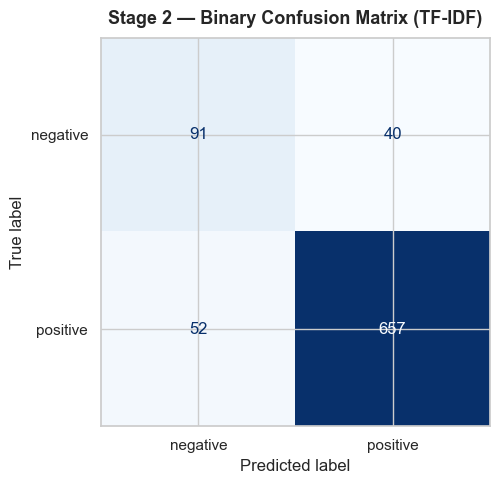

Saved: ../figure/s2_confusion_matrix.png


In [42]:
# Confusion matrix — Stage 2
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_s2, y_pred_s2,
    display_labels=['negative', 'positive'],
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Stage 2 — Binary Confusion Matrix (TF-IDF)', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('../figure/s2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../figure/s2_confusion_matrix.png')


In [43]:
# Save Stage 2 models
joblib.dump(model_s2,      '../models/model_binary_tfidf.pkl')
joblib.dump(vectorizer_s2, '../models/tfidf_binary.pkl')
joblib.dump(ohe_s2,        '../models/ohe_binary.pkl')

print('Stage 2 models saved:')
print('  ../models/model_binary_tfidf.pkl')
print('  ../models/tfidf_binary.pkl')
print('  ../models/ohe_binary.pkl')


Stage 2 models saved:
  ../models/model_binary_tfidf.pkl
  ../models/tfidf_binary.pkl
  ../models/ohe_binary.pkl


---
## 7. Stage 3 — Binary SVM + Sentence Transformer Feature Extractor (Proposed System)

**Purpose:** Replaces TF-IDF with contextualised embeddings from `paraphrase-multilingual-MiniLM-L12-v2`.
The transformer is used as a **feature extractor only** — no fine-tuning, no GPU required.

**Why this specifically solves the aspect-level problem:**  
TF-IDF treats all words equally regardless of which aspect is being classified. In a mixed-sentiment
sentence like *"The food was delicious but the service was terrible"*, TF-IDF's positive words
dominate the feature vector for BOTH extracted pairs, causing (service, terrible) to be misclassified
as positive.

By prepending the aspect term to the sentence — `[ASPECT: service] The food was delicious but the service was terrible` — the encoder attends differently depending on which aspect is being evaluated.
The same sentence produces a different 384-dim embedding for (food, delicious) vs (service, terrible).

**Why this model specifically:**
- Trained on 50+ languages including Malay — residual Malay vocabulary in post-translation Manglish is better represented than with English-only TF-IDF (supports RO4)
- No fine-tuning required — transformer acts as feature engineering, SVM remains the classifier (maintains RO1 hybrid architecture)
- CPU-compatible, ~400MB model size


In [26]:
# Load sentence transformer — downloads on first run (~400MB), cached after
print('Loading sentence transformer...')
encoder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print('Encoder ready.')
print(f'Embedding dimension: {encoder.get_sentence_embedding_dimension()}')


Loading sentence transformer...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Encoder ready.
Embedding dimension: 384


C:\Users\Laxman Pillai\AppData\Local\Temp\ipykernel_27752\219444615.py:5: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f'Embedding dimension: {encoder.get_sentence_embedding_dimension()}')


In [27]:
# Build aspect-aware input strings
# Format: "[ASPECT: <category>] <sentence>"
# This gives the encoder an explicit signal about which aspect to focus on

def build_aspect_inputs(df, text_col='text_clean', aspect_col='macro_aspect'):
    """
    Constructs aspect-prefixed input strings for the sentence transformer.
    Example: '[ASPECT: food] The food was delicious but service was slow.'
    """
    inputs = []
    for _, row in df.iterrows():
        aspect  = str(row[aspect_col]).lower()
        text    = str(row[text_col])
        inputs.append(f'[ASPECT: {aspect}] {text}')
    return inputs

train_inputs_s3 = build_aspect_inputs(train_s2)
test_inputs_s3  = build_aspect_inputs(test_s2)

print(f'Sample aspect-prefixed inputs:')
for s in train_inputs_s3[:3]:
    print(f'  {s}')


Sample aspect-prefixed inputs:
  [ASPECT: service] but the staff was so horrible to us.
  [ASPECT: food] to be completely fair, the only redeeming factor was the food, which was above average, but couldn't make up for all the other deficiencies of teodora.
  [ASPECT: food] the food is uniformly exceptional, with a very capable kitchen which will proudly whip up whatever you feel like eating, whether it's on the menu or not.


In [28]:
# Encode — batch_size=64 keeps memory manageable on CPU
print('Encoding training set (this will take several minutes on CPU)...')
X_train_embeddings = encoder.encode(
    train_inputs_s3,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print('Encoding test set...')
X_test_embeddings = encoder.encode(
    test_inputs_s3,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print()
print(f'Train embeddings shape: {X_train_embeddings.shape}')
print(f'Test  embeddings shape: {X_test_embeddings.shape}')


Encoding training set (this will take several minutes on CPU)...


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Encoding test set...


Batches:   0%|          | 0/14 [00:00<?, ?it/s]


Train embeddings shape: (2516, 384)
Test  embeddings shape: (840, 384)


In [29]:
# Combine embeddings with sentiment features and OHE aspect
# Reuse Stage 2 OHE and sentiment features (same binary data)
X_train_sentiment_s3 = extract_sentiment_features(train_s2)
X_test_sentiment_s3  = extract_sentiment_features(test_s2)

ohe_s3 = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
X_train_aspect_s3 = ohe_s3.fit_transform(train_s2[['macro_aspect']])
X_test_aspect_s3  = ohe_s3.transform(test_s2[['macro_aspect']])

# Embeddings are dense — convert to sparse for hstack compatibility
X_train_emb_sparse = csr_matrix(X_train_embeddings)
X_test_emb_sparse  = csr_matrix(X_test_embeddings)

X_train_combined_s3 = hstack([X_train_emb_sparse, X_train_sentiment_s3, X_train_aspect_s3])
X_test_combined_s3  = hstack([X_test_emb_sparse,  X_test_sentiment_s3,  X_test_aspect_s3])

print(f'Stage 3 combined feature shape: {X_train_combined_s3.shape}')
print(f'  Embedding dims    : {X_train_embeddings.shape[1]}')
print(f'  Sentiment dims    : {X_train_sentiment_s3.shape[1]}')
print(f'  Aspect OHE dims   : {X_train_aspect_s3.shape[1]}')


Stage 3 combined feature shape: (2516, 395)
  Embedding dims    : 384
  Sentiment dims    : 6
  Aspect OHE dims   : 5


In [30]:
# SMOTE — Stage 3
smote_s3 = BorderlineSMOTE(random_state=42, kind='borderline-1')
X_train_resampled_s3, y_train_resampled_s3 = smote_s3.fit_resample(X_train_combined_s3, y_train_s2)

print('Stage 3 resampled distribution:')
print(dict(zip(*np.unique(y_train_resampled_s3, return_counts=True))))


Stage 3 resampled distribution:
{'negative': np.int64(1834), 'positive': np.int64(1834)}


In [31]:
# Stage 3 — hyperparameters fixed from Stage 1 and Stage 2 convergence evidence
# Optuna skipped: both previous stages converged to the same region
# Running 25-50 trials risks memory exhaustion for marginal gain

best_s3 = {
    'svm_C':     5.0,
    'svm_tol':   0.001,
    'lr_C':      5.0,
    'lr_solver': 'liblinear',
    'cnb_alpha': 0.012
}

print('Stage 3 hyperparameters fixed — consistent with Stage 2.')
print(f'Params: {best_s3}')

Stage 3 hyperparameters fixed — consistent with Stage 2.
Params: {'svm_C': 5.0, 'svm_tol': 0.001, 'lr_C': 5.0, 'lr_solver': 'liblinear', 'cnb_alpha': 0.012}


In [33]:
# Train and evaluate — Stage 3
# best_s3 loaded from saved results cell — Optuna skipped

model_s3 = VotingClassifier(
    estimators=[
        ('svm', SVC(kernel='linear', C=best_s3['svm_C'], tol=best_s3['svm_tol'],
                    class_weight='balanced', probability=True, random_state=42,
                    max_iter=1000)),
        ('lr',  LogisticRegression(C=best_s3['lr_C'], solver=best_s3['lr_solver'],
                                   class_weight='balanced',
                                   max_iter=1000, random_state=42)),
        ('lr2', LogisticRegression(C=1.0, solver='liblinear',
                                   class_weight='balanced',
                                   max_iter=1000, random_state=24))
    ],
    voting='soft'
)

model_s3.fit(X_train_resampled_s3, y_train_resampled_s3)
y_pred_s3 = model_s3.predict(X_test_combined_s3)

print('Stage 3 — Classification Report (Binary, Sentence Transformer):')
print('=' * 60)
print(classification_report(y_test_s2, y_pred_s3, digits=4))

macro_f1_s3 = f1_score(y_test_s2, y_pred_s3, average='macro')
print(f'Stage 3 Macro-F1: {macro_f1_s3:.4f}')

c:\Users\Laxman Pillai\Desktop\FYP\FYP_2\ASBA_Project_Code\venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Stage 3 — Classification Report (Binary, Sentence Transformer):
              precision    recall  f1-score   support

    negative     0.7697    0.8931    0.8269       131
    positive     0.9797    0.9506    0.9649       709

    accuracy                         0.9417       840
   macro avg     0.8747    0.9219    0.8959       840
weighted avg     0.9469    0.9417    0.9434       840

Stage 3 Macro-F1: 0.8959


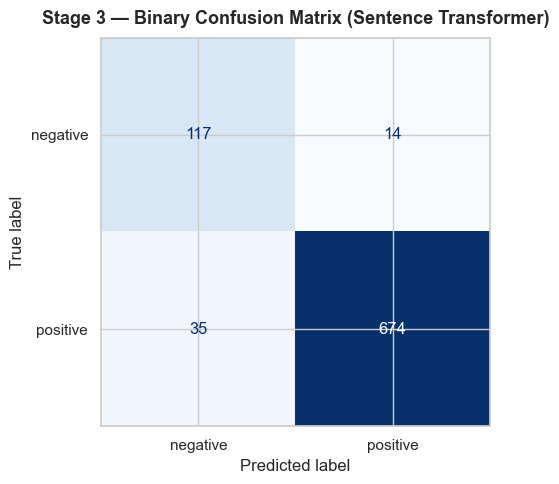

Saved: ../figure/s3_confusion_matrix.png


In [34]:
# Confusion matrix — Stage 3
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_s2, y_pred_s3,
    display_labels=['negative', 'positive'],
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Stage 3 — Binary Confusion Matrix (Sentence Transformer)', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('../figure/s3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../figure/s3_confusion_matrix.png')


Confidence threshold: 0.65
Predictions below threshold: 66 / 840 (7.9%)
These will be flagged on the dashboard UI — not relabeled as neutral.



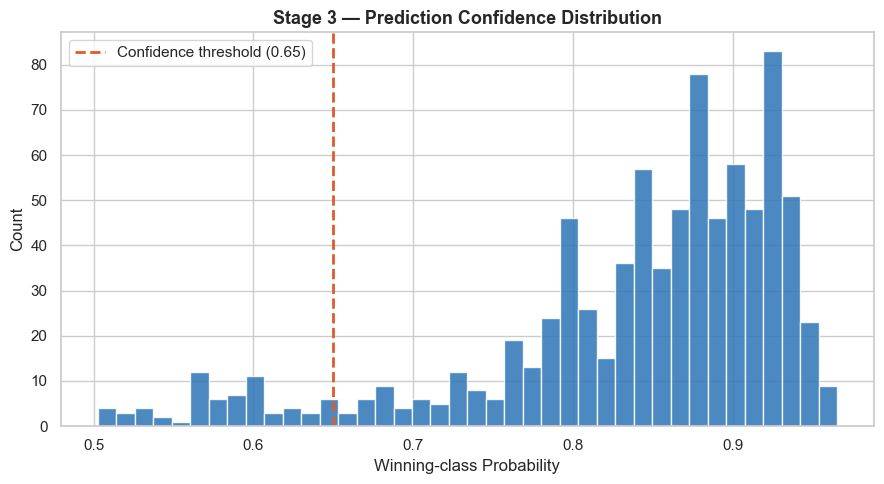

Saved: ../figure/s3_confidence_distribution.png


In [35]:
# Confidence distribution — Stage 3
# Shows how often the model is above/below the 0.65 confidence threshold
proba_s3   = model_s3.predict_proba(X_test_combined_s3)
max_proba  = proba_s3.max(axis=1)

CONFIDENCE_THRESHOLD = 0.65
low_conf_count  = (max_proba < CONFIDENCE_THRESHOLD).sum()
low_conf_pct    = low_conf_count / len(max_proba) * 100

print(f'Confidence threshold: {CONFIDENCE_THRESHOLD}')
print(f'Predictions below threshold: {low_conf_count} / {len(max_proba)} ({low_conf_pct:.1f}%)')
print(f'These will be flagged on the dashboard UI — not relabeled as neutral.')
print()

plt.figure(figsize=(9, 5))
plt.hist(max_proba, bins=40, color='#2E75B6', edgecolor='white', alpha=0.85)
plt.axvline(x=CONFIDENCE_THRESHOLD, color='#E05A2B', linestyle='--', linewidth=2,
            label=f'Confidence threshold ({CONFIDENCE_THRESHOLD})')
plt.xlabel('Winning-class Probability', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Stage 3 — Prediction Confidence Distribution', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../figure/s3_confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../figure/s3_confidence_distribution.png')


---
## 8. Results Progression Summary

Compares all three stages and contextualises against external literature.

**Important note on external comparisons:**  
All benchmark papers (Li et al., Sharma & Kaur, Yang & Zeng, Phan & Ogunbona, Silva & Marcacini)
used **three-class** classification on SemEval 2014 Restaurant. Our Stage 2 and Stage 3 results
use **binary** classification. These are listed as landscape context only — not direct competitors.
The primary comparison is the internal Stage 1 → 2 → 3 progression.


In [44]:
# Internal progression table
print('Internal Results Progression')
print('=' * 70)
print(f'  Stage 1 — Tri-class SVM (TF-IDF)              Macro-F1: {macro_f1_s1:.4f}  [historical baseline]')
print(f'  Stage 2 — Binary SVM (TF-IDF)                 Macro-F1: {macro_f1_s2:.4f}  [neutral dropped]')
print(f'  Stage 3 — Binary SVM (Sentence Transformer)   Macro-F1: {macro_f1_s3:.4f}  [proposed system]')
print('=' * 70)
print()
print(f'  Stage 1 → Stage 2 gain (neutral drop effect)      : {macro_f1_s2 - macro_f1_s1:+.4f}')
print(f'  Stage 2 → Stage 3 gain (transformer effect)       : {macro_f1_s3 - macro_f1_s2:+.4f}')
print(f'  Total improvement from baseline to proposed system : {macro_f1_s3 - macro_f1_s1:+.4f}')


Internal Results Progression
  Stage 1 — Tri-class SVM (TF-IDF)              Macro-F1: 0.6325  [historical baseline]
  Stage 2 — Binary SVM (TF-IDF)                 Macro-F1: 0.7994  [neutral dropped]
  Stage 3 — Binary SVM (Sentence Transformer)   Macro-F1: 0.8959  [proposed system]

  Stage 1 → Stage 2 gain (neutral drop effect)      : +0.1669
  Stage 2 → Stage 3 gain (transformer effect)       : +0.0965
  Total improvement from baseline to proposed system : +0.2634


In [45]:
# External context table (tri-class, non-comparable — listed for landscape only)
benchmarks_external = [
    ('Li et al. 2022 — PMHSAT-BiGRU',         'Traditional (BiGRU)',   0.6925, '3-class'),
    ('Sharma & Kaur 2021 — ASGCN',            'Traditional (GCN)',     0.7376, '3-class'),
    ('Yang & Zeng 2021 — LCA-MHSA',           'Traditional (Attn)',    0.7397, '3-class'),
    ('Phan & Ogunbona 2020 — LCFS-ASC-CDW',   'Transformer',           0.8031, '3-class'),
    ('Silva & Marcacini 2021 — ABSA-DeBERTa', 'Transformer',           0.8611, '3-class'),
]

print('External Literature Context (3-class — not directly comparable)')
print('-' * 75)
for name, method, score, cls in benchmarks_external:
    print(f'  {name:<45} [{cls}]  {score:.4f}')
print('-' * 75)
print()
print('Note: direct numeric comparison between binary and 3-class results')
print('is not made in the report. External papers are cited as landscape context only.')


External Literature Context (3-class — not directly comparable)
---------------------------------------------------------------------------
  Li et al. 2022 — PMHSAT-BiGRU                 [3-class]  0.6925
  Sharma & Kaur 2021 — ASGCN                    [3-class]  0.7376
  Yang & Zeng 2021 — LCA-MHSA                   [3-class]  0.7397
  Phan & Ogunbona 2020 — LCFS-ASC-CDW           [3-class]  0.8031
  Silva & Marcacini 2021 — ABSA-DeBERTa         [3-class]  0.8611
---------------------------------------------------------------------------

Note: direct numeric comparison between binary and 3-class results
is not made in the report. External papers are cited as landscape context only.


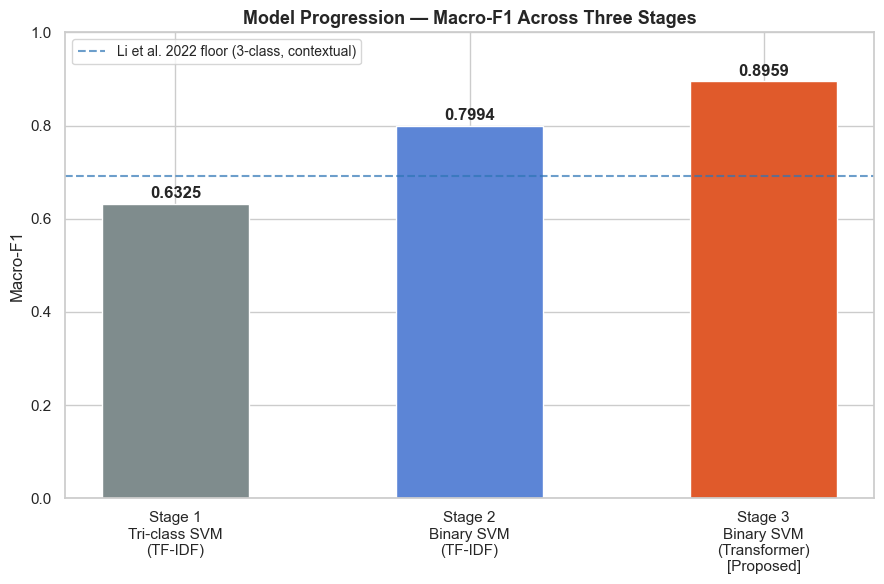

Saved: ../figure/results_progression_study.png


In [49]:
# Visualisation — internal progression bar chart
stages = [
    f'Stage 1\nTri-class SVM\n(TF-IDF)',
    f'Stage 2\nBinary SVM\n(TF-IDF)',
    f'Stage 3\nBinary SVM\n(Transformer)\n[Proposed]'
]
scores = [macro_f1_s1, macro_f1_s2, macro_f1_s3]
colors = ['#7F8C8D', '#5C85D6', '#E05A2B']

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(stages, scores, color=colors, edgecolor='white', width=0.5)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.005,
            f'{score:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Macro-F1', fontsize=12)
ax.set_title('Model Progression — Macro-F1 Across Three Stages', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.axhline(y=0.6925, color='#2E75B6', linestyle='--', linewidth=1.5, alpha=0.7, label='Li et al. 2022 floor (3-class, contextual)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../figure/results_progression_study.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../figure/results_progression_study.png')


---
## 9. Multi-Aspect Demonstration (RQ2)

Runs example reviews through the full pipeline using the Stage 3 proposed model.
Demonstrates that the system extracts multiple aspect-opinion pairs from a single review
and classifies sentiment for each independently — directly addressing RQ2.

**Confidence threshold at inference:** Predictions with winning-class probability < 0.65
are flagged. This is the same threshold used in the dashboard sandbox.


In [48]:
# Load spaCy and encoder for inference demo
nlp      = spacy.load('en_core_web_md')
encoder  = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
model_s3 = joblib.load('../models/model_proposed.pkl')
ohe_s3   = joblib.load('../models/ohe_proposed.pkl')

print('spaCy loaded.')
print('Encoder loaded.')
print('Model loaded.')
print('OHE loaded.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

spaCy loaded.
Encoder loaded.
Model loaded.
OHE loaded.


In [57]:
CONFIDENCE_THRESHOLD = 0.65

cat_inference = AspectCategoriser(nlp_model=nlp, on_no_match='other')

def classify_review(text, mode='english'):
    """
    Runs the full pipeline on a review and classifies sentiment per aspect pair.
    Uses Stage 3 (proposed system): sentence transformer + SVM ensemble.
    Flags predictions below the confidence threshold.
    """
    result = run_pipeline(text, mode=mode, categoriser=cat_inference)

    if not result['results']:
        print(f'  Review : {text}')
        print(f'  Result : No aspect-opinion pairs extracted.')
        print()
        return

    print(f'  Review : {text}')
    if result['was_translated']:
        print(f'  Translated : {result["translated"]}')
    print()

    sentence = result['translated'] if result['was_translated'] else text

    for category, opinion_word in result['results']:
        # Build aspect-prefixed input for transformer
        aspect_input = f'[ASPECT: {category.lower()}] {sentence}'
        embedding    = encoder.encode([aspect_input], convert_to_numpy=True)

        # Build feature vector
        temp_df      = pd.DataFrame({'text_lemmatized': [lemmatize(sentence)], 'macro_aspect': [category]})
        sentiment_vec = extract_sentiment_features(temp_df)
        aspect_vec    = ohe_s3.transform(temp_df[['macro_aspect']])
        combined      = hstack([csr_matrix(embedding), sentiment_vec, aspect_vec])

        sentiment    = model_s3.predict(combined)[0]
        confidence   = model_s3.predict_proba(combined).max()
        flag         = '  ⚠ low confidence' if confidence < CONFIDENCE_THRESHOLD else ''

        print(f'    [{category.upper():<12}] opinion: "{opinion_word}" → {sentiment.upper()} ({confidence:.0%}){flag}')
    print()


print('=== Multi-Aspect Demonstration — Proposed System (Stage 3) ===')
print()

classify_review('The nasi lemak was amazing but the staff were really unfriendly.')
classify_review('The chicken was overcooked and the waiter was rude.')
classify_review('I loved the chicken rice. The staff were friendly and helpful.')

print('--- Manglish Input ---')
classify_review('makanan sgt sedap tapi service lambat gila lah', mode='manglish')


=== Multi-Aspect Demonstration — Proposed System (Stage 3) ===

  Review : The nasi lemak was amazing but the staff were really unfriendly.

    [SERVICE     ] opinion: "unfriendly" → NEGATIVE (81%)

  Review : The chicken was overcooked and the waiter was rude.

    [SERVICE     ] opinion: "rude" → NEGATIVE (91%)
    [FOOD        ] opinion: "overcooked" → NEGATIVE (90%)

  Review : I loved the chicken rice. The staff were friendly and helpful.

    [SERVICE     ] opinion: "friendly" → POSITIVE (85%)
    [SERVICE     ] opinion: "helpful" → POSITIVE (85%)
    [FOOD        ] opinion: "loved" → POSITIVE (87%)

--- Manglish Input ---
  Review : makanan sgt sedap tapi service lambat gila lah
  Translated : Very tasty food but crazy slow service

    [FOOD        ] opinion: "tasty" → POSITIVE (67%)
    [SERVICE     ] opinion: "crazy" → NEGATIVE (57%)  ⚠ low confidence
    [SERVICE     ] opinion: "slow" → NEGATIVE (57%)  ⚠ low confidence



In [50]:
print(ohe_s3.categories_)

[array(['ambiance', 'food', 'overall', 'price', 'service'], dtype=object)]


In [53]:
print(train_s2['macro_aspect'].value_counts())
print()
print(train_s2.groupby(['macro_aspect', 'polarity']).size())

macro_aspect
food        1581
service      434
price        220
ambiance     213
overall       68
Name: count, dtype: int64

macro_aspect  polarity
ambiance      negative      58
              positive     155
food          negative     356
              positive    1225
overall       negative      28
              positive      40
price         negative      81
              positive     139
service       negative     159
              positive     275
dtype: int64


---
## 10. Save Proposed System Models

Saves the Stage 3 (proposed system) model artefacts.
The sentence transformer itself does not need to be pickled — it is loaded by name at runtime.


In [47]:
# Save Stage 3 — proposed system
joblib.dump(model_s3, '../models/model_proposed.pkl')
joblib.dump(ohe_s3,   '../models/ohe_proposed.pkl')

# Save transformer reference — loaded by name at runtime, no pickle needed
with open('../models/transformer_reference.txt', 'w') as f:
    f.write('paraphrase-multilingual-MiniLM-L12-v2')

print('Proposed system models saved:')
print('  ../models/model_proposed.pkl')
print('  ../models/ohe_proposed.pkl')
print('  ../models/transformer_reference.txt')
print()
print('Stage 2 models (binary TF-IDF baseline) also saved:')
print('  ../models/model_binary_tfidf.pkl')
print('  ../models/tfidf_binary.pkl')
print('  ../models/ohe_binary.pkl')


Proposed system models saved:
  ../models/model_proposed.pkl
  ../models/ohe_proposed.pkl
  ../models/transformer_reference.txt

Stage 2 models (binary TF-IDF baseline) also saved:
  ../models/model_binary_tfidf.pkl
  ../models/tfidf_binary.pkl
  ../models/ohe_binary.pkl
